# Lab 04: Vector Spatial Analysis

## BIO597 Spatial Analysis of Biodiversity

This lab uses Maine amphibian occurrence records together with conserved lands, HUC12 watersheds, and major roads. Each section starts with a biological or conservation question and introduces one spatial operation that can help answer it.

## Goals

By the end of this lab, you should be able to:

* explain why vector layers need a coordinate reference system
* use a spatial join to connect points with polygons
* create a buffer using a distance measured in meters
* summarize occurrence records by watershed
* find the nearest road to each occurrence
* use intersection and difference to compare polygon layers

## The vector layers

We will use four kinds of vector data:

* **points:** amphibian occurrence records
* **polygons:** conserved lands
* **polygons:** HUC12 watersheds
* **lines:** primary and secondary roads

The shapefiles are in `ME_ShapeFiles`. See the README in that directory for the source and limitations of each layer. The road layer contains major roads, not every local road.

## 1. Import packages

`pandas` reads the occurrence table. `geopandas` reads and analyzes spatial data.

In [1]:
import pandas as pd
import geopandas as gpd

## 2. Load the occurrence records

This is the same tab-delimited GBIF file used in Assignment 03. We will keep only the columns needed for today's spatial questions.

In [2]:
amphibians = pd.read_csv(
    "../assignments/Amphibians_ME/Amphibians_ME.csv",
    sep="\t",
    low_memory=False,
)

amphibians.shape

# low_memory=False prevents that DTypeWarning message, this tells pandas to read the entire file at once rather than in chunks

(25972, 50)

In [3]:
columns_to_keep = [
    "gbifID",
    "species",
    "decimalLongitude",
    "decimalLatitude",
    "coordinateUncertaintyInMeters",
    "year",
]

amphibians = amphibians[columns_to_keep]
amphibians.head()

,gbifID,species,decimalLongitude,decimalLatitude,coordinateUncertaintyInMeters,year
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,5.0,2026.0
1,6520735611,Aquarana clamitans,-69.649014,44.735713,10.0,2026.0
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,10236.0,2026.0
3,6520721493,Lithobates palustris,-68.636788,44.860466,112.0,2022.0
4,6520718655,Lithobates pipiens,-68.788851,44.990948,1187.0,2026.0


## 3. Prepare the coordinates

Spatial analysis requires usable numeric coordinates. Convert longitude and latitude to numbers, then remove records that are missing a species name or either coordinate.

In [4]:
amphibians["decimalLongitude"] = pd.to_numeric(
    amphibians["decimalLongitude"], errors="coerce"
)
amphibians["decimalLatitude"] = pd.to_numeric(
    amphibians["decimalLatitude"], errors="coerce"
)

In [5]:
amphibians = amphibians.dropna(
    subset=["species", "decimalLongitude", "decimalLatitude"]
).copy()

amphibians.shape

(25586, 6)

## 4. Create a GeoDataFrame

GBIF coordinates use longitude and latitude. `EPSG:4326` describes that coordinate reference system.

In [6]:
amphibians_gdf = gpd.GeoDataFrame(
    amphibians,
    geometry=gpd.points_from_xy(
        amphibians["decimalLongitude"],
        amphibians["decimalLatitude"],
    ),
    crs="EPSG:4326",
)

amphibians_gdf.head()

,gbifID,species,decimalLongitude,decimalLatitude,coordinateUncertaintyInMeters,year,geometry
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,5.0,2026.0,POINT (-68.66028 44.90255)
1,6520735611,Aquarana clamitans,-69.649014,44.735713,10.0,2026.0,POINT (-69.64901 44.73571)
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,10236.0,2026.0,POINT (-69.88924 44.79832)
3,6520721493,Lithobates palustris,-68.636788,44.860466,112.0,2022.0,POINT (-68.63679 44.86047)
4,6520718655,Lithobates pipiens,-68.788851,44.990948,1187.0,2026.0,POINT (-68.78885 44.99095)


## 5. Load the Maine vector layers

`gpd.read_file()` can read a shapefile directly. Remember that the other files beside each `.shp` file are also parts of the shapefile and must stay together.

In [7]:
# .shp is a standard, geospatial format for vector data

conserved = gpd.read_file("ME_ShapeFiles/Maine_Conserved_Lands.shp")
watersheds = gpd.read_file("ME_ShapeFiles/Maine_HUC12_Watersheds.shp")
roads = gpd.read_file("ME_ShapeFiles/Maine_Primary_Secondary_Roads.shp")

## 6. Inspect geometry types and coordinate systems

The geometry type tells us what each row represents. The CRS tells us how coordinates are stored.

In [8]:
# We are going to ask what geometry is being used and what coordinate reference system is being used, using plot() as a low memory fix for computer

print("Occurrences:", amphibians_gdf.geometry.geom_type.unique(), amphibians_gdf.crs)
print("Conserved lands:", conserved.geometry.geom_type.unique(), conserved.crs)
print("Watersheds:", watersheds.geometry.geom_type.unique(), watersheds.crs)
print("Roads:", roads.geometry.geom_type.unique(), roads.crs)

Occurrences: <StringArray>
['Point']
Length: 1, dtype: str EPSG:4326
Conserved lands: <StringArray>
['Polygon', 'MultiPolygon', nan]
Length: 3, dtype: str EPSG:4326
Watersheds: <StringArray>
['Polygon', 'MultiPolygon']
Length: 2, dtype: str EPSG:4326
Roads: <StringArray>
['LineString']
Length: 1, dtype: str EPSG:4269


## 7. Make quick maps

First inspect each layer separately. Interactive maps are useful for checking whether a layer is in the expected location.

<Axes: >

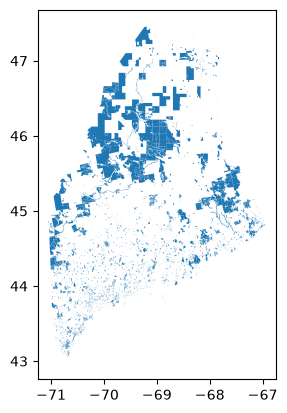

In [9]:
conserved.explore(tooltip=["PARCEL_NAM", "CONS1_TYPE", "PUB_ACCESS"])
conserved.plot()

<Axes: >

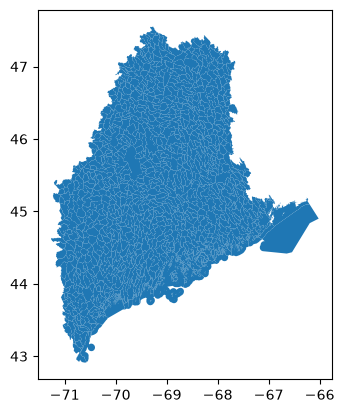

In [10]:
watersheds.explore(tooltip=["huc12", "name"])
watersheds.plot()

<Axes: >

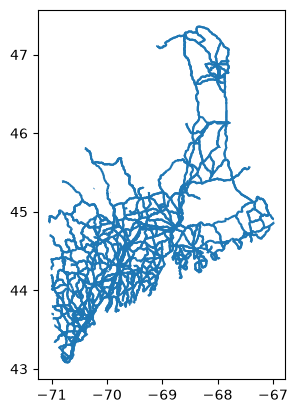

In [11]:
roads.explore(tooltip=["FULLNAME", "MTFCC"])
roads.plot()

## 8. Project the layers before measuring distance

Longitude and latitude are measured in degrees. Buffers and distances are easier to interpret in a projected CRS whose units are meters.

We will use [`EPSG:26919`](https://epsg.io/32619), UTM Zone 19N, for Maine. Every layer used in the same spatial operation must use the same CRS.

In [12]:
maine_crs = "EPSG:26919"

amphibians_projected = amphibians_gdf.to_crs(maine_crs)
conserved_projected = conserved.to_crs(maine_crs)
watersheds_projected = watersheds.to_crs(maine_crs)
roads_projected = roads.to_crs(maine_crs)

In [13]:
print(amphibians_projected.crs)
print(conserved_projected.crs)
print(watersheds_projected.crs)
print(roads_projected.crs)

EPSG:26919
EPSG:26919
EPSG:26919
EPSG:26919


# Question 1: Which amphibian records occur inside conserved lands?

A **spatial join** adds attributes from one spatial layer to another according to a spatial relationship. Here, an occurrence point matches a conserved-land polygon when the point is `within` that polygon.

We use an inner join because we only want matching occurrence records.

In [14]:
# order is important for the dataframe and the spatial join is .sjoin()

conserved_columns = ["PARCEL_NAM", "CONS1_TYPE", "PUB_ACCESS", "geometry"]

occurrences_in_conserved = gpd.sjoin(
    amphibians_projected,
    conserved_projected[conserved_columns],
    how="inner",
    predicate="within",
)

print(amphibians_projected.shape, occurrences_in_conserved.shape)
occurrences_in_conserved.head()

(25586, 7) (7505, 11)


,gbifID,species,decimalLongitude,decimalLatitude,coordinateUncertaintyInMeters,year,geometry,index_right,PARCEL_NAM,CONS1_TYPE,PUB_ACCESS
7,6520700408,Lithobates palustris,-69.865662,44.361917,4.0,2026.0,POINT (431019.46 4912435.936),58,Allen Whitney Memorial Forest,Fee,Contact landowner for additional information
9,6520670325,Boreorana sylvatica,-70.411203,43.454942,4.0,2025.0,POINT (385826.652 4812304.652),8773,NaN,Easement,Contact landowner for additional information
11,6520663387,Lithobates palustris,-69.811887,43.815353,13.0,2026.0,POINT (434705.98 4851685.25),3105,Center Pond Prreserve,Fee,Contact landowner for additional information
12,6520635193,Boreorana sylvatica,-70.389796,43.954013,27411.0,2026.0,POINT (388487.785 4867704.185),5240,NaN,Easement,Restricted - land owner permission required
17,6520610648,Aquarana clamitans,-70.399019,43.934882,NaN,2026.0,POINT (387711.745 4865591.845),10102,L.A. Marshall Co.,Fee,Contact landowner for additional information


One occurrence can match more than one overlapping conservation polygon. Count unique `gbifID` values when the question is about occurrence records.

In [15]:
unique_conserved_records = occurrences_in_conserved.drop_duplicates(subset="gbifID")

len(unique_conserved_records)

7473

In [16]:
conserved_species_counts = unique_conserved_records["species"].value_counts()
conserved_species_counts

species
Lithobates catesbeianus       1207
Plethodon cinereus            1110
Anaxyrus americanus           1039
Aquarana clamitans             883
Ambystoma maculatum            630
Boreorana sylvatica            601
Lithobates palustris           575
Pseudacris crucifer            382
Notophthalmus viridescens      332
Dryophytes versicolor          189
Eurycea bislineata             153
Lithobates pipiens             141
Aquarana septentrionalis        76
Hemidactylium scutatum          44
Desmognathus fuscus             36
Ambystoma laterale              32
Gyrinophilus porphyriticus      28
Aquarana catesbeiana            11
Ambystoma jeffersonianum         2
Osteopilus septentrionalis       1
Pseudacris regilla               1
Name: count, dtype: int64

Map the matching points. Convert them back to longitude and latitude so the interactive basemap aligns correctly.

<Axes: >

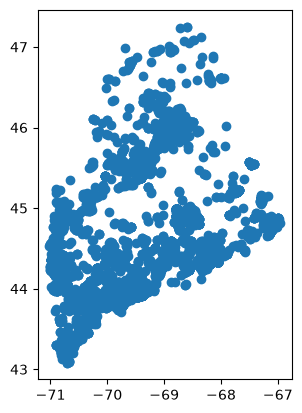

In [17]:
# unique_conserved_records.to_crs("EPSG:4326").explore(
#    column="species",
#    tooltip=["species", "PARCEL_NAM", "PUB_ACCESS"],
#)
unique_conserved_records.to_crs("EPSG:4326").plot()

# Question 2: Which watershed contains each occurrence?

HUC12 polygons represent small drainage areas. A point-in-polygon spatial join can assign each occurrence to a watershed.

In [18]:
watershed_columns = ["huc12", "name", "geometry"]

occurrences_by_watershed = gpd.sjoin(
    amphibians_projected,
    watersheds_projected[watershed_columns],
    how="inner",
    predicate="within",
)

occurrences_by_watershed.head()

,gbifID,species,decimalLongitude,decimalLatitude,coordinateUncertaintyInMeters,year,geometry,index_right,huc12,name
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,5.0,2026.0,POINT (526820.667 4972181.261),703,010200050603,Marsh Island-Penobscot River
1,6520735611,Aquarana clamitans,-69.649014,44.735713,10.0,2026.0,POINT (448613.081 4953797.105),806,010300031501,Eaton Ridge-Kennebec River
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,10236.0,2026.0,POINT (429668.678 4960931.931),803,010300031301,Getchell Brook-Kennebec River
3,6520721493,Lithobates palustris,-68.636788,44.860466,112.0,2022.0,POINT (528696.105 4967514.248),703,010200050603,Marsh Island-Penobscot River
4,6520718655,Lithobates pipiens,-68.788851,44.990948,1187.0,2026.0,POINT (516644.128 4981966.564),694,010200050508,Lower Dead Stream


Now change the unit of analysis from individual occurrence records to watersheds. For each watershed, count unique records and unique species.

In [19]:
watershed_summary = occurrences_by_watershed.groupby(
    ["huc12", "name"]
).agg(
    records=("gbifID", "nunique"),
    species_count=("species", "nunique"),
)

watershed_summary = watershed_summary.reset_index()
watershed_summary.head()

,huc12,name,records,species_count
0,010100020101,Smith Brook,10,6
1,010100020103,Soper Brook,1,1
2,010100020105,Woodman Brook-Eagle Lake,9,5
3,010100020202,North Twin Brook,2,2
4,010100020204,Churchill Lake,9,5


In [20]:
watershed_summary.sort_values("species_count", ascending=False).head(10)

,huc12,name,records,species_count
766,010600020402,Kezar Lake,151,16
306,010200050707,Lower Kenduskeag Stream,158,16
320,010200051003,Felts Brook-Penobscot River,218,16
348,010300010510,Moosehead Lake,84,16
299,010200050603,Marsh Island-Penobscot River,365,16
296,010200050510,Stillwater River,459,16
737,010600010110,Sebago Lake,225,15
473,010300032305,Cobbosseecontee Lake,104,15
803,010600030402,Leighs Mill Pond-Great Works River,220,15
810,010600031102,Stevens Brook-Frontal Atlantic Ocean,196,15


Join the summary back to the watershed polygons so the counts can be mapped.

In [21]:
watersheds_with_counts = watersheds_projected.merge(
    watershed_summary,
    on=["huc12", "name"],
    how="left",
)

<Axes: >

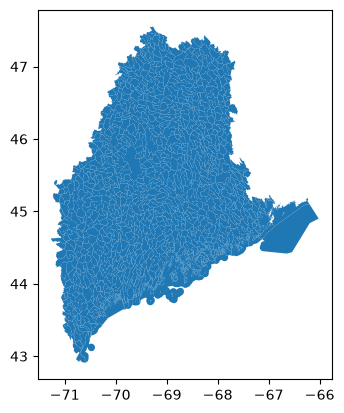

In [22]:
# watersheds_with_counts.to_crs("EPSG:4326").explore(
#    column="species_count",
#    tooltip=["name", "huc12", "records", "species_count"],
#)
watersheds_with_counts.to_crs("EPSG:4326").plot()

# Question 3: How many species have records within 500 m of a major road?

A **buffer** creates a polygon covering all locations within a chosen distance of a feature. Because these roads are projected in meters, a buffer distance of `500` means 500 meters.

In [23]:
road_buffer_geometry = roads_projected.buffer(500)

print(road_buffer_geometry.shape)
road_buffer_geometry.head()

(5007,)


0    POLYGON ((371754.067 4843052.555, 371743.14 48...
1    POLYGON ((397210.576 4834483.533, 397210.02 48...
2    POLYGON ((356453.644 4772377.903, 356472.43 47...
3    POLYGON ((356298.964 4772202.086, 356299.439 4...
4    POLYGON ((422325.027 4865837.325, 422336.944 4...
dtype: geometry

The individual road buffers overlap. `union_all()` combines them into one geometry so an occurrence is not counted repeatedly for several nearby road segments.

In [24]:
road_buffer_union = road_buffer_geometry.union_all()

road_buffer = gpd.GeoDataFrame(
    {"buffer_m": [500]},
    geometry=[road_buffer_union],
    crs=maine_crs,
)

road_buffer.shape

(1, 2)

In [25]:
occurrences_near_roads = gpd.sjoin(
    amphibians_projected,
    road_buffer,
    how="inner",
    predicate="within",
)

occurrences_near_roads.shape

(7047, 9)

In [26]:
species_near_roads = occurrences_near_roads["species"].nunique()
species_near_roads

24

In [27]:
occurrences_near_roads["species"].value_counts()

species
Boreorana sylvatica           839
Pseudacris crucifer           809
Aquarana clamitans            793
Lithobates catesbeianus       767
Anaxyrus americanus           705
Plethodon cinereus            693
Ambystoma maculatum           645
Dryophytes versicolor         443
Lithobates palustris          424
Notophthalmus viridescens     288
Eurycea bislineata            136
Lithobates pipiens            121
Ambystoma laterale             80
Desmognathus fuscus            80
Hemidactylium scutatum         71
Gyrinophilus porphyriticus     43
Ambystoma jeffersonianum       31
Aquarana catesbeiana           28
Aquarana septentrionalis       22
Rana arvalis                   17
Necturus maculosus              9
Pseudacris regilla              1
Ambystoma tigrinum              1
Rana halecina                   1
Name: count, dtype: int64

This result is about proximity to **primary and secondary roads**. It does not measure proximity to every local road, and it does not show that roads caused the observed pattern.

# Question 4: How far is each occurrence from the nearest major road?

`sjoin_nearest()` finds the closest feature in another layer. The new `distance_to_road_m` column records the distance because our projected CRS uses meters.

In [28]:
road_columns = ["FULLNAME", "MTFCC", "geometry"]

nearest_roads = gpd.sjoin_nearest(
    amphibians_projected,
    roads_projected[road_columns],
    how="left",
    distance_col="distance_to_road_m",
)

nearest_roads.head()

,gbifID,species,decimalLongitude,decimalLatitude,coordinateUncertaintyInMeters,year,geometry,index_right,FULLNAME,MTFCC,distance_to_road_m
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,5.0,2026.0,POINT (526820.667 4972181.261),4227,Park St,S1200,657.168440
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,5.0,2026.0,POINT (526820.667 4972181.261),4212,US Hwy 2,S1200,657.168440
1,6520735611,Aquarana clamitans,-69.649014,44.735713,10.0,2026.0,POINT (448613.081 4953797.105),804,Waterville Rd,S1200,139.960689
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,10236.0,2026.0,POINT (429668.678 4960931.931),3111,Main St,S1200,25.261092
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,10236.0,2026.0,POINT (429668.678 4960931.931),3675,State Rte 148,S1200,25.261092


In [29]:
nearest_roads["distance_to_road_m"].describe()

count    52886.000000
mean      3152.761048
std       6960.846542
min          0.010127
25%        452.684542
50%       1365.331569
75%       2817.357506
max      90686.824513
Name: distance_to_road_m, dtype: float64

The nearest-road distances form a one-column distance matrix: every occurrence has a distance to its closest road. A complete distance matrix would compare every occurrence with every road or every other occurrence, which would be much larger.

# Polygon overlay: intersection and difference

An **intersection** keeps places shared by two layers. A **difference** keeps places in the first layer that are not covered by the second.

To keep this example small, use the watershed with the most occurrence records.

In [30]:
top_watershed = watershed_summary.sort_values(
    "records", ascending=False
).iloc[0]

top_huc12 = top_watershed["huc12"]
top_huc12

'010500021407'

In [31]:
study_watershed = watersheds_projected[
    watersheds_projected["huc12"] == top_huc12
].copy()

study_watershed[["huc12", "name"]]

,huc12,name
181,010500021407,Northeast Creek-Frontal Frenchman Bay


First clip the conserved lands to the watershed using intersection.

In [32]:
conserved_in_watershed = gpd.overlay(
    conserved_projected,
    study_watershed,
    how="intersection",
)

conserved_in_watershed.shape

(43, 40)

`dissolve()` demonstrates a union-like operation by combining the intersecting conserved parcels. We then use difference to retain the part of the watershed outside those conserved parcels.

In [33]:
conserved_union = conserved_in_watershed.dissolve()

unconserved_part = gpd.overlay(
    study_watershed,
    conserved_union,
    how="difference",
)
m = study_watershed.explore()
unconserved_part.explore(m=m)

In [34]:
conserved_area_km2 = conserved_in_watershed.area.sum() / 1_000_000
watershed_area_km2 = study_watershed.area.sum() / 1_000_000

100 * conserved_area_km2 / watershed_area_km2

np.float64(59.23765644336575)

The percentage above is a geometric estimate based on the supplied layers. Conserved lands are approximate planning boundaries, and this calculation should not be treated as a legal acreage determination.

## Discussion questions

1. How did the unit of analysis change when we summarized occurrence records by watershed?  Longitude and latitude are measured in degrees. Buffers and distances are easier to interpret in a projected CRS whose units are meters.
2. Why was a projected CRS required for the 500 m buffer and nearest-road distance? You need to find the nearest road by finding the shortest straight line distance. 
3. Why might occurrence records be especially common near roads even if roads are not good amphibian habitat? Sampling bias, easy access for sampling, road kill, ditches, easier to find.
4. What information is lost when overlapping road buffers are combined with `union_all()`? Wouldn't you not be able to tell which part of the polygon came from what road because it's all in one big polygon? So you lost the information regarding the specific road?
5. Which result in this notebook is most sensitive to sampling bias? Occurence records because of sampling bias of roads.

## Practice submitting your work to GitHub

Run the notebook from top to bottom. Save it, then add, commit, and push the notebook from a terminal.

```bash
git add docs/labs/Lab04-VectorSpatialAnalysis.ipynb
git commit -m "Complete vector spatial analysis lab"
git push
```